
---

### Declaration of Usage of Generative AI
In this work, Generative AI was used to post-edit the wording of **some** written paragraphs and comments, including the ones in the final report, to improve their clarity and style, as English is not the native language of any of the group members. The underlying ideas and content remain entirely our own. In terms of coding, AI assistance was used **solely** for debugging purposes when exceptions occurred in the code. **No** generative AI tools were used as a learning assistant during the completion of this exercise.

---



# Exercise 5: LLM Prompting and Prompt Engineering Part 2

In part 2, we experiment with prompting instruction-tuned Large Language Models (LLMs), and evaluate their performance on a linguistic annotation task involving structured outputs.

The goal of this assignment is to gain some experience working with instruction-tuned LLMs. To this end, you will learn how to

- query an instruction-tuned LLM with default chat templates (`Llama-3.2-3B-Instruct`)
- parse LLM outputs for structured responses using JSON and `Pydantic`
- implement error handling for edge cases where the model fails to output the expected data format.

The task we use for this purpose is a simple Tokenization and Part-of-Speech tagging task using data taken from Universal Dependencies.

To facilitate working with LLMs, we will again use the Unsloth library. Note that Unsloth provides both freeware and closed-source proprietary software. For our purposes, the freeware is sufficient! For more information on Unsloth, see the docs here.

This notebook is adapted from [this example](https://colab.research.google.com/drive/1T5-zKWM_5OD21QHwXHiV9ixTRR7k3iB9?usp=sharing) by Unsloth.


### NOTE: Expected execution times
We have provided expected execution times throughout the notebook as a guide. These are intended to be approximate, but should give you some idea for what to expect. If your runtimes far exceed these expected execution times, you may want to consider modifying your approach. These are denoted with ⌛ .

### NOTE: GPU Usage
It is expected that you load the model onto a GPU for inference. For other parts of the code, such as data preparation, a GPU is not necessary. To avoid waiting for resources unnecessarily, we recommend doing as much as you can on a CPU instance and change the runtime type as necessary. We've highlight the cells that need a GPU with ⚡

## 1) Installing dependencies

In [1]:
%%capture
!pip install levenshtein

import re
import torch; v = re.match(r"[0-9\.]{3,}", str(torch.__version__)).group(0)
xformers = "xformers==" + ("0.0.32.post2" if v == "2.8.0" else "0.0.29.post3")
!pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
!pip install sentencepiece protobuf "datasets>=3.4.1,<4.0.0" "huggingface_hub>=0.34.0" hf_transfer
!pip install --no-deps unsloth

!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

In [2]:
# check gpu info
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

# check RAM info
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Sat Nov 29 11:55:21 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2) Model Loading

In [3]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 2048 # Choose any! We auto support RoPE Scaling internally!
dtype = None # None for auto detection. Float16 for Tesla T4, V100, Bfloat16 for Ampere+
load_in_4bit = True # Use 4bit quantization to reduce memory usage. Can be False.

# Note, here we specify the instruction-tuned version of Llama-3.2-3B
model_name = "unsloth/Llama-3.2-3B-Instruct"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = model_name,
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
    # token = "hf_...", # use one if using gated models like meta-llama/Llama-2-7b-hf
)

# Set tokenizer padding side
tokenizer.padding_side = "left"

FastLanguageModel.for_inference(model) # Enable native 2x faster inference

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


    PyTorch 2.6.0+cu124 with CUDA 1204 (you have 2.9.0+cu126)
    Python  3.12.9 (you have 3.12.12)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details


Switching to PyTorch attention since your Xformers is broken.

Unsloth: Xformers was not installed correctly.
Please install xformers separately first.
Then confirm if it's correctly installed by running:
python -m xformers.info

Longer error message:
xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.6.0+cu124 with CUDA 1204 (you have 2.9.0+cu126)
    Python  3.12.9 (you have 3.12.12)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.11.4: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/

model.safetensors:   0%|          | 0.00/2.35G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 3072, padding_idx=128004)
    (layers): ModuleList(
      (0): LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=3072, out_features=3072, bias=False)
          (k_proj): Linear4bit(in_features=3072, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=3072, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=3072, out_features=3072, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=3072, out_features=8192, bias=False)
          (up_proj): Linear4bit(in_features=3072, out_features=8192, bias=False)
          (down_proj): Linear4bit(in_features=8192, out_features=3072, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((3072,)

## 3) Data Loading and Preparation

In [4]:
# load data
import random
import pandas as pd

seed = 42

random.seed(seed)

dataset_url = "https://raw.githubusercontent.com/tannonk/prompting_exercise/refs/heads/main/data/en_ewt-ud-dev-pos.json"
df = pd.read_json(dataset_url, lines=True)

# For each input sentence, we'll build the target as a list of dictionaries containing keys for the token and pos tag. This is what we want our LLM annotator to predict.
df['target'] = df.apply(lambda x: [{'token': token, 'pos': pos} for token, pos in zip(x['tokens'].split(), x['upos'].split())], axis=1)

# We'll sample 100 items for testing purposes
test_data = df.sample(n=100, random_state=seed)
train_data = df.drop(test_data.index)

print(f"Train data: {len(train_data)}")
print(f"Test data: {len(test_data)}")

test_data.head()


Train data: 1408
Test data: 100


,sentence,tokens,upos,xpos,target
578,"""...there is no companion quite so devoted, so...",""" ... there is no companion quite so devoted ,...",PUNCT PUNCT PRON VERB DET NOUN ADV ADV ADJ PUN...,"`` , EX VBZ DT NN RB RB JJ , RB JJ , RB JJ CC ...","[{'token': '""', 'pos': 'PUNCT'}, {'token': '....."
1146,"Great computer repair store, highly recommended.","Great computer repair store , highly recommend...",ADJ NOUN NOUN NOUN PUNCT ADV VERB PUNCT,"JJ NN NN NN , RB VBN .","[{'token': 'Great', 'pos': 'ADJ'}, {'token': '..."
382,You wear your heart on your sleeve ... and sin...,You wear your heart on your sleeve ... and sin...,PRON VERB PRON NOUN ADP PRON NOUN PUNCT CCONJ ...,"PRP VBP PRP$ NN IN PRP$ NN , CC IN PRP VBP DT ...","[{'token': 'You', 'pos': 'PRON'}, {'token': 'w..."
583,for Books that Speak for Themselves....,for Books that Speak for Themselves ....,ADP NOUN PRON VERB ADP PRON PUNCT,"IN NNS WDT VBP IN PRP ,","[{'token': 'for', 'pos': 'ADP'}, {'token': 'Bo..."
966,yuck !!,yuck !!,INTJ PUNCT,UH .,"[{'token': 'yuck', 'pos': 'INTJ'}, {'token': '..."


In [5]:
from collections import Counter

# Calculating the frequency of each UPOS tag
upos_tag_counts = []
for row in test_data['upos']:
    upos_tag_counts.extend(row.split())

# Displaying the result
print("Frequency of each UPOS tag:")
Counter(upos_tag_counts)

Frequency of each UPOS tag:


Counter({'PUNCT': 146,
         'PRON': 106,
         'VERB': 124,
         'DET': 88,
         'NOUN': 219,
         'ADV': 69,
         'ADJ': 111,
         'CCONJ': 41,
         'ADP': 99,
         'SCONJ': 13,
         'AUX': 72,
         'PART': 17,
         'INTJ': 6,
         'PROPN': 69,
         'NUM': 16,
         'X': 1,
         'SYM': 3})

### TODO: Inspect and describe the data

📝❓ What are the fields and their corresponding values in the dataframe?

✅ Each row in the DataFrame contains `sentence`, `tokens`, `upos`, `xpos`, and `target`.
* `sentence` is the original sentence as a single string.
* `tokens` is the space-separated, tokenized version of the sentence.
* `upos` is the space-separated sequence of Universal POS tags.
* `xpos` is the space-separated sequence of language-specific POS tags.
* `target` is a list of dictionaries, where each element has the form `{"token": token, "pos": upos_tag}`.

📝❓ What is the difference between `upos` and `xpos`?

✅ `upos` are Universal POS tags, which form a standardized tagset across languages, for example, NOUN, ADJ, VERB, ADV. `xpos` are language-specific POS tags. They are detailed and dataset-specific, for example, NN, VBZ, PRP$.

📝❓ What is the distribution of `upos` labels in the `test_data`?

✅ Based on the UPOS tag frequencies above, the most frequent tag is **NOUN** (219 occurrences), followed by **PUNCT** (146), **VERB** (124) and **ADJ** (111). The rarest tag is **X**, which appears only once in the `test_data` set.

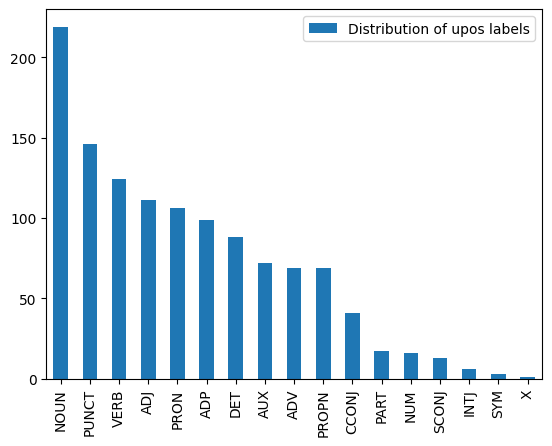

In [6]:
import matplotlib.pyplot as plt

# Plot a bar plot to visualize the distribution
upos_df = (pd.DataFrame.from_dict(Counter(upos_tag_counts),
                                  orient='index',
                                  columns=['Distribution of upos labels'])
                       .sort_values('Distribution of upos labels',
                                    ascending=False))
upos_df.plot.bar()
plt.show()

### TODO: Define the basic `PromptTemplate`

Note, you can reuse the solution from part 1 of this exercise here.

In [7]:
import json
from typing import List, Dict
from pydantic import BaseModel
from transformers import PreTrainedModel, PreTrainedTokenizerBase

class PromptTemplate:
    def __init__(self,
                 task_description: str,
                 bos: str = tokenizer.bos_token,
                 eos: str = "\n\n"):

        self.task_description = task_description
        self.bos = bos # Used for training prompt formatting
        self.eos = eos # Used for training prompt formatting

    def build_chat_prompts(self,
                           test_data: pd.DataFrame,
                           train_data: pd.DataFrame,
                           tokenizer: PreTrainedTokenizerBase,
                           n_shots: int = 4) -> List:

      chat_list = []

      # Build prompts for the indicated number of shots
      for _, test_sample in test_data.iterrows():

        # Sample n_shots training examples to use as few-shot context
        examples = train_data.sample(n=n_shots, random_state=42).to_dict(orient="records")

        # Start the dialogue for this sample with high-level instruction as a system message
        dialogue = [{"role": "system", "content": self.task_description}]

        # Build the few-shot prompt for this test example
        for example in examples:
            dialogue.append({"role": "user", "content": example["input"]})
            dialogue.append({"role": "assistant", "content": json.dumps(example["output"])})

        # Add the actual query sentence
        dialogue.append({"role": "user", "content": test_sample["input"]})

        # Convert using the model's chat template
        chat = tokenizer.apply_chat_template(dialogue,
                                             tokenize=False)
        chat_list.append(chat)

      return chat_list

## 3.2 ChatTemplates

Instruction-tuned models are typically finetuned using a predefined `ChatTemplate`.
This means that when using them for inference, it is important that we use the correct `ChatTemplate` in order to avoid "confusing" the model.

You can find more information about model `ChatTemplates` for Huggingface models [here](https://huggingface.co/docs/transformers/en/chat_templating).


In [8]:
from unsloth.chat_templates import get_chat_template

# load the chat_template from unsloth (note, the logic is similar when using native Huggingface, but here we're using Unsloth!)
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "llama-3.1", # for Llama-3.1 and Llama-3.2 models
)

# Set tokenizer padding side
tokenizer.padding_side = "left"

# Inspect the template (note, it looks more complicated than it is!)
print(tokenizer.chat_template)


{{- bos_token }}
{%- if custom_tools is defined %}
    {%- set tools = custom_tools %}
{%- endif %}
{%- if not tools_in_user_message is defined %}
    {%- set tools_in_user_message = true %}
{%- endif %}
{%- if not date_string is defined %}
    {%- set date_string = "26 July 2024" %}
{%- endif %}
{%- if not tools is defined %}
    {%- set tools = none %}
{%- endif %}

{#- This block extracts the system message, so we can slot it into the right place. #}
{%- if messages[0]['role'] == 'system' %}
    {%- set system_message = messages[0]['content'] %}
    {%- set messages = messages[1:] %}
{%- else %}
    {%- set system_message = "" %}
{%- endif %}

{#- System message + builtin tools #}
{{- "<|start_header_id|>system<|end_header_id|>

" }}
{%- if builtin_tools is defined or tools is not none %}
    {{- "Environment: ipython
" }}
{%- endif %}
{%- if builtin_tools is defined %}
    {{- "Tools: " + builtin_tools | reject('equalto', 'code_interpreter') | join(", ") + "

"}}
{%- endif %}
{{- "

### TODO: Prepare your inputs using the `ChatTemplate` for the model.

Note, you should be able to drop your custom `PromptTemplate` string into the model's default `ChatTemplate`.


In [9]:
# Keep only the colums we work with and rename them correspondingly
train_data = train_data[['sentence', 'target']].rename(columns={'sentence': 'input', 'target': 'output'})
test_data = test_data[['sentence', 'target']].rename(columns={'sentence': 'input', 'target': 'output'})

# Initialise prompt template with basic instruction
task_description = 'Tokenize, assign POS tags to the following sentences. Output as a list of JSON objects.'
prompt_template = PromptTemplate(task_description)

# Build model's default chat templates
chat_list = prompt_template.build_chat_prompts(test_data=test_data,
                                               train_data=train_data,
                                               tokenizer=tokenizer)

print("First chat prompt:")
print(chat_list[0])

First chat prompt:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 July 2024

Tokenize, assign POS tags to the following sentences. Output as a list of JSON objects.<|eot_id|><|start_header_id|>user<|end_header_id|>

Not sure if I am going to buy 17" or 16" wheels for the winter.<|eot_id|><|start_header_id|>assistant<|end_header_id|>

[{"token": "Not", "pos": "PART"}, {"token": "sure", "pos": "ADJ"}, {"token": "if", "pos": "SCONJ"}, {"token": "I", "pos": "PRON"}, {"token": "am", "pos": "AUX"}, {"token": "going", "pos": "VERB"}, {"token": "to", "pos": "PART"}, {"token": "buy", "pos": "VERB"}, {"token": "17", "pos": "NUM"}, {"token": "\"", "pos": "NOUN"}, {"token": "or", "pos": "CCONJ"}, {"token": "16", "pos": "NUM"}, {"token": "\"", "pos": "NOUN"}, {"token": "wheels", "pos": "NOUN"}, {"token": "for", "pos": "ADP"}, {"token": "the", "pos": "DET"}, {"token": "winter", "pos": "NOUN"}, {"token": ".", "pos": "PUNCT"}]<|eot_id|

## 4) Inference Pipeline

### TODO: Define a function to run inference efficiently with an LLM

Note, you can use the same inference function from part 1 of this exercise here!

In [10]:
# Set up our inference pipeline for generation

# We'll set some default generation args that we'll pass to our inference function
# Following best practices, we'll use Pydantic class which helps with validation.
from pydantic import BaseModel

class Generation_Args(BaseModel):
    max_new_tokens: int
    temperature: float
    top_k: int
    top_p: float
    repetition_penalty: float
    do_sample: bool
    min_p: float
    num_return_sequences: int

# Here are some default generation args
generation_args = Generation_Args(
    max_new_tokens = 1024, # note, for this task, we're setting the max_new_tokens to be more appropriate
    temperature = 1.0,
    top_k = 0,
    top_p = 1.0,
    repetition_penalty = 1.0,
    do_sample = True,
    use_cache = True,
    min_p = 0.1,
    num_return_sequences = 1
)


def run_batched_inference(prompts: List[str],
                          model: PreTrainedModel,
                          tokenizer: PreTrainedTokenizerBase,
                          batch_size: int = 1,
                          generation_args: Generation_Args = generation_args) -> List[str]:
    """
    Run generation in batches to avoid OOM issues.
    Prompts are encoded, moved to the correct device, and passed
    through the model with the specified decoding settings.
    """

    tokenizer.padding_side = "left"

    outputs = []

    # Run batched generation for memory-efficient, high-throughput inference
    for i in range(0, len(prompts), batch_size):
        batch_prompts = prompts[i:i + batch_size]

        # Tokenize the current batch and move it to the model device.
        # - padding=True: pad to the longest sequence in the batch for efficient batching
        # - truncation=True: clip inputs that exceed the model's maximum context length
        inputs = tokenizer(batch_prompts,
                           return_tensors="pt",
                           padding=True,
                           truncation=True).to(model.device)  # Move the inputs to the same device as model

        # Generate continuations for the batch.
        # - generation_args.dict(): plug in the config values
        # - pad_token_id / eos_token_id: make sure generation and padding use a valid token
        # - use_cache=True: for faster autoregressive decoding
        with torch.no_grad():
            generated = model.generate(**inputs,
                                       **generation_args.model_dump(),
                                       pad_token_id=tokenizer.pad_token_id,
                                       eos_token_id=tokenizer.eos_token_id,
                                       use_cache=True)

        # Decode token IDs back into text and accumulate results
        decoded = tokenizer.batch_decode(generated,
                                         skip_special_tokens=True)
        outputs.extend(decoded)

    return outputs

## 4.1) Run Inference

### TODO: run inference!

⌛ 10-20 mins

⚡ GPU

In [11]:
raw_outputs = run_batched_inference(prompts=chat_list,
                                    model=model,
                                    tokenizer=tokenizer)

print('The first element of the raw model outputs:\n', raw_outputs[0])

The first element of the raw model outputs:
 system

Cutting Knowledge Date: December 2023
Today Date: 26 July 2024

Tokenize, assign POS tags to the following sentences. Output as a list of JSON objects.user

Not sure if I am going to buy 17" or 16" wheels for the winter.assistant

[{"token": "Not", "pos": "PART"}, {"token": "sure", "pos": "ADJ"}, {"token": "if", "pos": "SCONJ"}, {"token": "I", "pos": "PRON"}, {"token": "am", "pos": "AUX"}, {"token": "going", "pos": "VERB"}, {"token": "to", "pos": "PART"}, {"token": "buy", "pos": "VERB"}, {"token": "17", "pos": "NUM"}, {"token": "\"", "pos": "NOUN"}, {"token": "or", "pos": "CCONJ"}, {"token": "16", "pos": "NUM"}, {"token": "\"", "pos": "NOUN"}, {"token": "wheels", "pos": "NOUN"}, {"token": "for", "pos": "ADP"}, {"token": "the", "pos": "DET"}, {"token": "winter", "pos": "NOUN"}, {"token": ".", "pos": "PUNCT"}]user

Privacy in kerala,help pls..?assistant

[{"token": "Privacy", "pos": "NOUN"}, {"token": "in", "pos": "ADP"}, {"token": "ke

## 5) Structured output validation

LLMs output text. But in practice, we often want structured data that we can process further with other automatic processes.

For this purpose, JSON is a good target data structure.


### TODO: Define a processing pipeline that extracts and validates the JSON response from the LLM.

Hint: For this you should use a combination of [`Regex`](https://www.w3schools.com/python/python_regex.asp) and [`Pydantic`](https://docs.pydantic.dev/latest/).

The output should be a valid json object with the following structure:

```json
[
    {"token": "there", "pos": "DET"}, # each dict contains a token and its corresponding POS-Tag.
    {"token": "is", "pos": "VERB"},
    {"token": "no", "pos": "ADJ"},
    {"token": "companion", "pos": "NOUN"},
    {"token": "quite", "pos": "ADV"},
    {"token": "so", "pos": "ADV"},
    {"token": "devoted", "pos": "ADV"},
    {"token": "so", "pos": "ADV"},
    ...
]
```

In [12]:
import re
import json
from typing import List
from pydantic import BaseModel, ValidationError


class TokenTag(BaseModel):
    token: str
    pos: str


def get_structured_outputs(raw_outputs: List[str]) -> List[List[Dict[str, str]]]:
  """
  Extract and validate all `"token": "...", "pos": "..."` pairs
  from a list of LLM outputs.

  Args:
      raw_outputs (list): List of raw LLM output strings.

  Returns:
      A list (one per output) of validated dictionaries
      of the form {"token": str, "pos": str}.
  """

  # Regular expression to extract "token": "..." and "pos": "..."
  pair_pattern = re.compile(r'"token"\s*:\s*"([^"]+)"\s*,\s*"pos"\s*:\s*"([^"]+)"',
                            re.MULTILINE)

  results = []

  for idx, text in enumerate(raw_outputs):

    # Find all token-pos pairs anywhere in the text
    matches = pair_pattern.findall(text)

    valid_matches = []

    for token, pos in matches:
      try:

        obj = TokenTag(token=token, pos=pos)
        valid_matches.append(obj.model_dump())

      except ValidationError:

        # Skip invalid pairs
        continue

    if not valid_matches:
        print(f"No valid token-pos pairs found for output index {idx}.")

    results.append(valid_matches)

  return results

In [13]:
# Obtain a valid JSON object from LLM output
structured_outputs = get_structured_outputs(raw_outputs=raw_outputs)

print('The first element of the structured model outputs:\n', structured_outputs[0])

The first element of the structured model outputs:
 [{'token': 'Not', 'pos': 'PART'}, {'token': 'sure', 'pos': 'ADJ'}, {'token': 'if', 'pos': 'SCONJ'}, {'token': 'I', 'pos': 'PRON'}, {'token': 'am', 'pos': 'AUX'}, {'token': 'going', 'pos': 'VERB'}, {'token': 'to', 'pos': 'PART'}, {'token': 'buy', 'pos': 'VERB'}, {'token': '17', 'pos': 'NUM'}, {'token': 'or', 'pos': 'CCONJ'}, {'token': '16', 'pos': 'NUM'}, {'token': 'wheels', 'pos': 'NOUN'}, {'token': 'for', 'pos': 'ADP'}, {'token': 'the', 'pos': 'DET'}, {'token': 'winter', 'pos': 'NOUN'}, {'token': '.', 'pos': 'PUNCT'}, {'token': 'Privacy', 'pos': 'NOUN'}, {'token': 'in', 'pos': 'ADP'}, {'token': 'kerala', 'pos': 'PROPN'}, {'token': ',', 'pos': 'PUNCT'}, {'token': 'help', 'pos': 'VERB'}, {'token': 'pls', 'pos': 'INTJ'}, {'token': '..?', 'pos': 'PUNCT'}, {'token': 'They', 'pos': 'PRON'}, {'token': 'are', 'pos': 'AUX'}, {'token': 'very', 'pos': 'ADV'}, {'token': 'good', 'pos': 'ADJ'}, {'token': 'teachers', 'pos': 'NOUN'}, {'token': 'and'

## 6) *Evaluation*

In [14]:
# Below is some boilerplate evaluation code. You should not need to make any changes here.

import Levenshtein
import numpy as np
from typing import List, Dict

def evaluate_instance(target: List[Dict], prediction: List[Dict]):
    """
    Evaluates the accuracy of tokenization and part-of-speech (POS) tagging between a target and a predicted sequence.

    Args:
        target (List[Dict]): A list of dictionaries representing the target tokens and POS tags.
        prediction (List[Dict]): A list of dictionaries representing the predicted tokens and POS tags.

    Returns:
        dict: A dictionary containing the token-level accuracy ('Token Acc') and POS accuracy ('POS Acc').
    """

    # If there is no prediction, return zero accuracies
    if prediction is None:
        return {'Token Acc': 0, 'POS Acc': 0}

    # Extract tokens and POS tags from the target and prediction lists
    target_tokens = [item['token'] for item in target]
    target_pos = [item['pos'] for item in target]
    pred_tokens = [item['token'] for item in prediction]
    pred_pos = [item['pos'] for item in prediction]

    # Get alignment operations between the target and predicted tokens using Levenshtein.opcodes()
    opcodes = Levenshtein.opcodes(target_tokens, pred_tokens)

    # Initialize aligned lists to store tokens and POS tags after alignment
    aligned_target_tokens = []
    aligned_target_pos = []
    aligned_pred_tokens = []
    aligned_pred_pos = []

    # Iterate over each operation in the alignment
    for tag, i1, i2, j1, j2 in opcodes:
        # "equal" means the tokens in this range are identical in both sequences
        if tag == 'equal':
            aligned_target_tokens.extend(target_tokens[i1:i2])
            aligned_target_pos.extend(target_pos[i1:i2])
            aligned_pred_tokens.extend(pred_tokens[j1:j2])
            aligned_pred_pos.extend(pred_pos[j1:j2])
        # "replace" means tokens in this range are different between the target and prediction
        elif tag == 'replace':
            aligned_target_tokens.extend(target_tokens[i1:i2])
            aligned_target_pos.extend(target_pos[i1:i2])
            aligned_pred_tokens.extend(pred_tokens[j1:j2])
            aligned_pred_pos.extend(pred_pos[j1:j2])
        # "insert" means tokens were added in the prediction that are not in the target
        elif tag == 'insert':
            aligned_target_tokens.extend(['<MISSING>'] * (j2 - j1))  # Add placeholders for missing target tokens
            aligned_target_pos.extend(['<MISSING>'] * (j2 - j1))      # Add placeholders for missing target POS tags
            aligned_pred_tokens.extend(pred_tokens[j1:j2])
            aligned_pred_pos.extend(pred_pos[j1:j2])
        # "delete" means tokens are present in the target but missing in the prediction
        elif tag == 'delete':
            aligned_target_tokens.extend(target_tokens[i1:i2])
            aligned_target_pos.extend(target_pos[i1:i2])
            aligned_pred_tokens.extend(['<MISSING>'] * (i2 - i1))    # Add placeholders for missing predicted tokens
            aligned_pred_pos.extend(['<MISSING>'] * (i2 - i1))       # Add placeholders for missing predicted POS tags

    # Calculate token-level accuracy
    # We only consider positions where both target and prediction have valid tokens (i.e., not '<MISSING>')
    correct_tokens = [
        1 if tgt == pred else 0
        for tgt, pred in zip(aligned_target_tokens, aligned_pred_tokens)
        if tgt != '<MISSING>' and pred != '<MISSING>'
    ]
    token_accuracy = np.mean(correct_tokens) if correct_tokens else 0

    # Calculate POS accuracy
    # Only consider positions where tokens match and are not '<MISSING>'
    correct_pos = [
        1 if tgt_pos == pred_pos else 0
        for tgt_tok, pred_tok, tgt_pos, pred_pos in zip(aligned_target_tokens, aligned_pred_tokens, aligned_target_pos, aligned_pred_pos)
        if tgt_tok == pred_tok and tgt_tok != '<MISSING>'
    ]
    pos_accuracy = np.mean(correct_pos) if correct_pos else 0

    return {'Token Acc': token_accuracy, 'POS Acc': pos_accuracy}

def get_results(test_data: pd.DataFrame, processed_outputs: List[List[Dict]]):
    """
    Returns a summary dataframe by taking the average of the all results for tokenization and pos-tagging.
    """
    results = []
    for i in range(len(processed_outputs)):
        results.append(evaluate_instance(test_data.iloc[i]['output'], processed_outputs[i]))

    results = pd.DataFrame(results).mean()
    return results

In [15]:
# To get the results, you should be able to pass your test_data DataFrame and the structured_outputs from above...
get_results(test_data, structured_outputs)

,0
Token Acc,0.965273
POS Acc,0.731979


## 7) Manipulating the system prompt

The system prompt is part of the `ChatTemplate` that can help to steer the model.


### TODO: Customise the system prompt for the intended task and re-run inference

Note, this is an experiment. You should try a few different system prompts and report the resulting performance in your report.

⌛ 10-20 mins (per experiment run)

⚡ GPU

In [16]:
# Try teo other formulations of the prompt
task_description1 = 'Tokenize, and do some part of Speech tagging.'
task_description2 = 'You are a deterministic POS-tagging model designed to analyze text with POS tags. ' + \
                    'Follow these steps exactly: 1. Perform tokenization and part-of-speech (POS) tagging on the provided input sentences. ' + \
                    '2. For each word or token in the sentence, annotate it with the correct POS tag based on linguistic conventions. ' + \
                    '3. No explanations, no comments, and no text outside the JSON array.'

# Cast it into the PromptTemplate
prompt_template1 = PromptTemplate(task_description1)
prompt_template2 = PromptTemplate(task_description2)

In [17]:
def evaluation_pipeline(prompt_template: PromptTemplate,
                        train_data: pd.DataFrame = train_data,
                        test_data: pd.DataFrame = test_data,
                        tokenizer: PreTrainedTokenizerBase = tokenizer):

  # Build chat prompt templates given the provided PromptTemplate
  chat_list = prompt_template.build_chat_prompts(train_data=train_data,
                                                 test_data=test_data,
                                                 tokenizer=tokenizer)

  # Get a list of LLM string outputs
  raw_outputs = run_batched_inference(prompts=chat_list,
                                      model=model,
                                      tokenizer=tokenizer)

  # Extract and validate JSON responses of the LLM
  structured_outputs = get_structured_outputs(raw_outputs=raw_outputs)

  # Obtain tokenization and POS-tagging accuracies
  results = get_results(test_data, structured_outputs)

  return results

In [18]:
# Run the evaluation pipeline for the 1st prompt
results1 = evaluation_pipeline(prompt_template=prompt_template1)
results1

,0
Token Acc,0.956910
POS Acc,0.708018


In [19]:
# Run the evaluation pipeline for the 2nd prompt
results2 = evaluation_pipeline(prompt_template=prompt_template2)
results2

,0
Token Acc,0.939345
POS Acc,0.725624


📝❓ What was the best system prompt you considered?

✅ Based on both token and POS accuracies, the best prompt was `task_description`.

📝❓ Were you able to improve the performance by manipulating the system prompt? Please discuss.

✅  Yes, performance improved when we refined the system prompt. This is evident when comparing `task_description1` and `task_description2`. The first is shorter and less explicit about the model's role and the desired output, whereas the second clearly defines the model as a deterministic POS-tagging system and specifies the steps it should follow to perform the task. As a result, POS accuracy is higher for `task_description2` than for `task_description1`.

---

## 8) Lab report

📝❓ Write your lab report here addressing all questions in the notebook

✅
### 1. Introduction
In this notebook, we:

1. Applied an instruction-tuned LLM to the task of POS-tagging (and tokenization).
2. Experimented with manipulating the system prompt used to direct instruction-tuned models.

### 2. Methodology
#### 2.1 Data Preparation

We selected a subset of the UD English dataset, using 100 sentences as the test set. The `PromptTemplate` was defined using the `ChatTemplate` for *llama-3.1*.

#### 2.2 Efficient LLM Inference

We set up an inference pipeline for text generation. To avoid out-of-memory (OOM) issues, we implemented a `run_batched_inference` function that runs generation in batches.

#### 2.3 JSON Extraction and Validation

To facilitate downstream automatic processing, the LLM was instructed to output tokenization and POS tagging results in JSON format. We then extracted this JSON, validated its structure and content, and computed tokenization and POS tagging accuracies.

#### 2.4 System Prompt Customization

We experimented with different system prompts for the task and ran inference for each variant. This allowed us to compare their impact on performance by examining the resulting tokenization and POS tagging accuracies.

### 3. Results
The results are summarised below:

| Prompt ID           | System Prompt                                                                                                                      | Token Acc | POS Acc  |
|---------------------|-------------------------------------------------------------------------------------------------------------------------------------|-----------|----------|
| `task_description`  | Tokenize, assign POS tags to the following sentences. Output as a list of JSON objects.                                            | 0.965273  | 0.731979 |
| `task_description1` | Tokenize, and do some part of Speech tagging.                                                                                       | 0.956910  | 0.708018 |
| `task_description2` | You are a deterministic POS-tagging model designed to analyze text with POS tags.<br>Follow these steps exactly:<br>1. Perform tokenization and part-of-speech (POS) tagging on the provided input sentences.<br>2. For each word or token in the sentence, annotate it with the correct POS tag based on linguistic conventions.<br>3. No explanations, no comments, and no text outside the JSON array. | 0.939345  | 0.725624 |


### 5. Discussion

A stricter, more explicit system prompt produced more stable and cleaner JSON outputs. Overall, prompt design primarily improved the reliability and consistency of the results, rather than yielding large performance gains.


📝❓ What are the fields and their corresponding values in the dataframe?<br>
✅ Each row in the DataFrame contains `sentence`, `tokens`, `upos`, `xpos`, and `target`.
* `sentence` is the original sentence as a single string.
* `tokens` is the space-separated, tokenized version of the sentence.
* `upos` is the space-separated sequence of Universal POS tags.
* `xpos` is the space-separated sequence of language-specific POS tags.
* `target` is a list of dictionaries, where each element has the form `{"token": token, "pos": upos_tag}`.

<br>

📝❓ What is the difference between `upos` and `xpos`?<br>
✅ `upos` are Universal POS tags, which form a standardized tagset across languages, for example, NOUN, ADJ, VERB, ADV. `xpos` are language-specific POS tags. They are detailed and dataset-specific, for example, NN, VBZ, PRP$.

<br>

📝❓ What is the distribution of `upos` labels in the `test_data`?<br>
✅ Based on the UPOS tag frequencies above, the most frequent tag is **NOUN** (219 occurrences), followed by **PUNCT** (146), **VERB** (124) and **ADJ** (111). The rarest tag is **X**, which appears only once in the `test_data` set.

<br>

📝❓ What was the best system prompt you considered?<br>
✅ Based on both token and POS accuracy, the best prompt was `task_description`.

<br>

📝❓ Were you able to improve the performance by manipulating the system prompt? Please discuss.<br>
✅  Yes, performance improved when we refined the system prompt. This is evident when comparing `task_description1` and `task_description2`. The first is shorter and less explicit about the model's role and the desired output, whereas the second clearly defines the model as a deterministic POS-tagging system and specifies the steps it should follow to perform the task. As a result, POS accuracy is higher for `task_description2` than for `task_description1`.